In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

import numpy as np
import matplotlib.pyplot as plt

from tqdm.auto import tqdm

In [2]:
vocab = [
    # Numbers
    "0", "1", "2", "3", "4", "5", "6", "7", "8", "9",
    # Symbols
    "+", "=", ">",
    # Formatting
    "_", "\n"
]
print(f"Vocab size: {len(vocab)}")

Vocab size: 15


In [3]:
stoi = {s: i for i, s in enumerate(vocab)}
itos = {i: s for i, s in enumerate(vocab)}

def encode(text):
    return [stoi[s] for s in text]

def decode(ids):
    return ''.join([itos[i] for i in ids])

text = "__2+__3=___5\n"

print(f"text: {text}")
print(f"ids: {encode(text)}")
print(f"text: {decode(encode(text))}")

text: __2+__3=___5

ids: [13, 13, 2, 10, 13, 13, 3, 11, 13, 13, 13, 5, 14]
text: __2+__3=___5



In [4]:
def make_pair(text):
    ids = torch.tensor(encode(text), dtype=torch.long)

    x = ids[:-1]
    y = ids[1:]

    return x, y


x, y = make_pair(text)

print(f"input text: {decode(x.tolist())}")
print(f"target text: {decode(y.tolist())}")

input text: __2+__3=___5
target text: _2+__3=___5



In [5]:
def sopadd(a, b):
    text = f"{a:>3}+{b:>3}={a+b:>4}\n"
    return text.replace(" ", "_")


def make_dataset(n):
    texts = []

    for _ in range(n):
        a = torch.randint(0, 1000, (1,)).item()
        b = torch.randint(0, 1000, (1,)).item()

        text = sopadd(a, b)
        texts.append(text)

    pairs = [make_pair(text) for text in texts]

    x = torch.stack([p[0] for p in pairs])
    y = torch.stack([p[1] for p in pairs])

    return x, y, texts


x_train, y_train, train_texts = make_dataset(20000)
x_valid, y_valid, valid_texts = make_dataset(2000)

train_data = TensorDataset(x_train, y_train)
valid_data = TensorDataset(x_valid, y_valid)

train_loader = DataLoader(
    train_data,
    batch_size=128,
    shuffle=True
)

valid_loader = DataLoader(
    valid_data,
    batch_size=128,
    shuffle=False
)

In [6]:
# Random seed
torch.manual_seed(42)

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Model sizes
nvocab = len(vocab)             # Vocabulary size
ncontext = x_train.shape[1]     # Context length
nembed = 32                     # Token embedding dimension
nhead = 4                       # Attention heads
nlayer = 2                      # Transformer layers
dropout = 0.1                   # Dropout rate

# Training
lr = 1e-3
nepoch = 200

print("device =", device)
print("nvocab =", nvocab)
print("ncontext =", ncontext)
print("nembed =", nembed)
print("nhead =", nhead)
print("nlayer =", nlayer)
print("dropout =", dropout)
print("lr =", lr)
print("nepoch =", nepoch)

device = cuda
nvocab = 15
ncontext = 12
nembed = 32
nhead = 4
nlayer = 2
dropout = 0.1
lr = 0.001
nepoch = 200


In [7]:
# Multi transformer model
class MultiTransformer(nn.Module):
    def __init__(self):
        super().__init__()

        # Embeddings
        self.word_emb = nn.Embedding(nvocab, nembed)
        self.pos_emb = nn.Embedding(ncontext, nembed)

        # Transformer layer
        layer = nn.TransformerEncoderLayer(
            d_model=nembed,
            nhead=nhead,
            dim_feedforward=4 * nembed,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True
        )

        # Transformer blocks
        self.blocks = nn.TransformerEncoder(
            layer,
            num_layers=nlayer
        )

        # Output
        self.norm = nn.LayerNorm(nembed)
        self.out = nn.Linear(nembed, nvocab)

    def forward(self, X, Y=None):
        # Shapes
        B, T = X.shape

        # Positions
        pos = torch.arange(T, device=X.device)

        # Token + position embeddings
        H = self.word_emb(X) + self.pos_emb(pos)

        # Causal mask
        mask = torch.triu(
            torch.ones(T, T, device=X.device),
            diagonal=1).bool()

        # Transformer blocks
        H = self.blocks(H, mask=mask)

        # Normalize
        H = self.norm(H)

        # Vocabulary scores
        logits = self.out(H)

        # Loss
        loss = None
        if Y is not None:
            B, T, C = logits.shape
            loss = F.cross_entropy(
                logits.reshape(B * T, C),
                Y.reshape(B * T)
            )

        return logits, loss


model = MultiTransformer().to(device)
X = x_train.to(device)
Y = y_train.to(device)
logits, loss = model(X, Y)
print(model)
print("logits shape:", logits.shape)
print("loss:", loss.item())

/tmp/ipykernel_3035111/2720280692.py:22: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.blocks = nn.TransformerEncoder(


MultiTransformer(
  (word_emb): Embedding(15, 32)
  (pos_emb): Embedding(12, 32)
  (blocks): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=32, out_features=32, bias=True)
        )
        (linear1): Linear(in_features=32, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=128, out_features=32, bias=True)
        (norm1): LayerNorm((32,), eps=1e-05, elementwise_affine=True, bias=True)
        (norm2): LayerNorm((32,), eps=1e-05, elementwise_affine=True, bias=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (norm): LayerNorm((32,), eps=1e-05, elementwise_affine=True, bias=True)
  (out): Linear(in_features=32, out_features=15, bias=True)
)
logits shape: torch.Size([20000, 12, 15])
loss: 2.8421661853790

In [8]:
model = MultiTransformer().to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=lr)

history = {
    "train_loss": [],
    "valid_loss": [],
    "train_acc": [],
    "valid_acc": [],
}

progress = tqdm(range(nepoch), desc="training")

for epoch in progress:
    # Train
    model.train()

    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for X, Y in train_loader:
        X = X.to(device)
        Y = Y.to(device)

        logits, loss = model(X, Y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        n = Y.numel()
        train_loss += loss.item() * n
        train_total += n

        pred = logits.argmax(dim=-1)
        train_correct += (pred == Y).sum().item()

    train_loss = train_loss / train_total
    train_acc = train_correct / train_total

    # Valid
    model.eval()

    valid_loss = 0.0
    valid_correct = 0
    valid_total = 0

    with torch.no_grad():
        for X, Y in valid_loader:
            X = X.to(device)
            Y = Y.to(device)

            logits_v, loss_v = model(X, Y)

            n = Y.numel()
            valid_loss += loss_v.item() * n
            valid_total += n

            pred_v = logits_v.argmax(dim=-1)
            valid_correct += (pred_v == Y).sum().item()

    valid_loss = valid_loss / valid_total
    valid_acc = valid_correct / valid_total

    history["train_loss"].append(train_loss)
    history["valid_loss"].append(valid_loss)
    history["train_acc"].append(train_acc)
    history["valid_acc"].append(valid_acc)

    progress.set_postfix(
        train_loss=f"{train_loss:.4f}",
        valid_loss=f"{valid_loss:.4f}",
        train_acc=f"{100 * train_acc:.2f}%",
        valid_acc=f"{100 * valid_acc:.2f}%",
    )

/tmp/ipykernel_3035111/2720280692.py:22: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.blocks = nn.TransformerEncoder(


training:   0%|          | 0/200 [00:00<?, ?it/s]

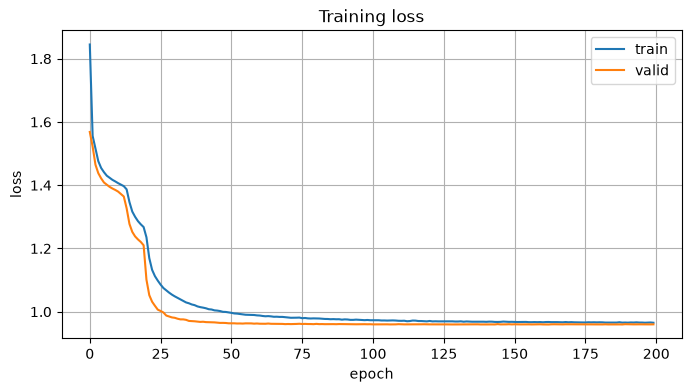

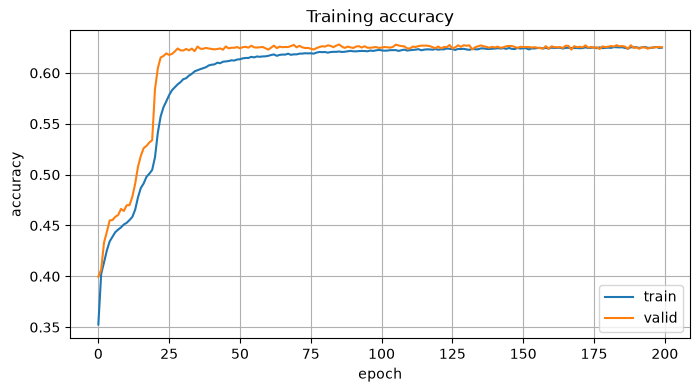

In [9]:
plt.figure(figsize=(8, 4))
plt.plot(history["train_loss"], label="train")
plt.plot(history["valid_loss"], label="valid")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("Training loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(history["train_acc"], label="train")
plt.plot(history["valid_acc"], label="valid")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.title("Training accuracy")
plt.legend()
plt.grid(True)
plt.show()

In [10]:
def generate(prompt, n):
    model.eval()

    ids = torch.tensor([encode(prompt)], dtype=torch.long, device=device)

    for _ in range(n):
        X = ids[:, -ncontext:]

        logits, _ = model(X)
        logits = logits[:, -1, :]

        next_id = torch.argmax(logits, dim=-1, keepdim=True)

        ids = torch.cat([ids, next_id], dim=1)

    return decode(ids[0].tolist())

In [11]:
print(generate("__1+__3=", 5))
print(generate("_12+_34=", 5))
print(generate("_99+000=", 5))

__1+__3=__94

_12+_34=__46

_99+000=__99

